In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

from scipy.stats import linregress

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

from studio_preprocessing_tools import *

In [2]:
ramr_wt = "MVARPKSEDKKQALLEAATQAIAQSGIAASTAVIARNAGVAEGTLFRYFATKDELINTLYLHLKQDLCQSMIMELDRSITDAKMMTRFIWNSYISWGLNHPARHRAIRQLAVSEKLTKETEQRADDMFPELRDLCHRSVLMVFMSDEYRAFGDGLFLALAETTMDFAARDPARAGEYIALGFEAMWRALTREEQ"
print("Sequence length:", len(ramr_wt))

ramr_ep = pd.read_csv("~/lab/SpecificityStudio/pg2/DMS_assays/raw_data/HTHTR_SALTY_dOelsnitz_2025/EP library.df_output_all.csv", index_col=0)
ramr_ep = ramr_ep.set_index("substitutions")
ramr_ep.loc['WT'] = ramr_ep.loc[ramr_ep.index.astype('str')=='nan'].mean(axis=0)
ramr_ss = pd.read_csv("~/lab/SpecificityStudio/pg2/DMS_assays/raw_data/HTHTR_SALTY_dOelsnitz_2025/SS library.df_output_all.csv", index_col=0)
ramr_ss = ramr_ss.set_index("substitutions")

ramr_dataset = pd.concat([ramr_ep, ramr_ss], axis=0)

print("Dataset size:", len(ramr_dataset))

Sequence length: 194
Dataset size: 150316


In [3]:
ramr_dataset_filt = ramr_dataset.loc[['*' not in str(subs) and 'nan' not in str(subs) for subs in ramr_dataset.index]]
ramr_dataset_filt = consolidate_duplicate_indices(ramr_dataset_filt)
print("Dataset size after filtering:", len(ramr_dataset_filt))

ramr_dataset = assign_mutant_column(ramr_dataset_filt)
ramr_dataset['n_subs'] = [i.count(':')+1 if i!='M1M' else 0 for i in ramr_dataset.mutant]
ramr_dataset['mutated_sequence'] = [apply_mutations(ramr_wt, muts) for muts in ramr_dataset.mutant]

Found 199 duplicate indices
Consolidated 139438 rows into 139233 rows
Dataset size after filtering: 139233


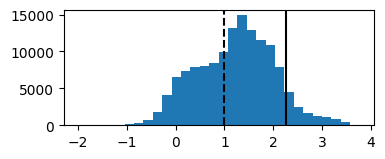

In [26]:
plt.figure(figsize=(4,1.5))

ramr_dataset['DMS_score'] = ramr_dataset['log_ginf_1-DIQ'] - ramr_dataset['log_g0']

ramr_dataset['fold_induction_1-DIQ_inf'] = ramr_dataset['log_ginf_1-DIQ'] - ramr_dataset['log_g0']
ramr_dataset['fold_induction_1R-TIQ_inf'] = ramr_dataset['log_ginf_1R-TIQ'] - ramr_dataset['log_g0']
ramr_dataset['fold_induction_1S-TIQ_inf'] = ramr_dataset['log_ginf_1S-TIQ'] - ramr_dataset['log_g0']

ramr_dataset['mean_fold_induction'] = ramr_dataset[['fold_induction_1-DIQ_inf', 'fold_induction_1R-TIQ_inf', 'fold_induction_1S-TIQ_inf']].mean(axis=1)

ramr_dataset['fold_induction_1-DIQ_500'] = ramr_dataset['GP_log_g500_1-DIQ'] - ramr_dataset['log_g0']
ramr_dataset['fold_induction_1R-TIQ_500'] = ramr_dataset['GP_log_g500_1R-TIQ'] - ramr_dataset['log_g0']
ramr_dataset['fold_induction_1S-TIQ_500'] = ramr_dataset['GP_log_g500_1S-TIQ'] - ramr_dataset['log_g0']

plt.figure(figsize=(4,1.5))
plt.hist(ramr_dataset['mean_fold_induction'], bins=30)
plt.axvline(ramr_dataset['mean_fold_induction'].loc['WT'], c='k')
plt.axvline(1., c='k', ls='--')

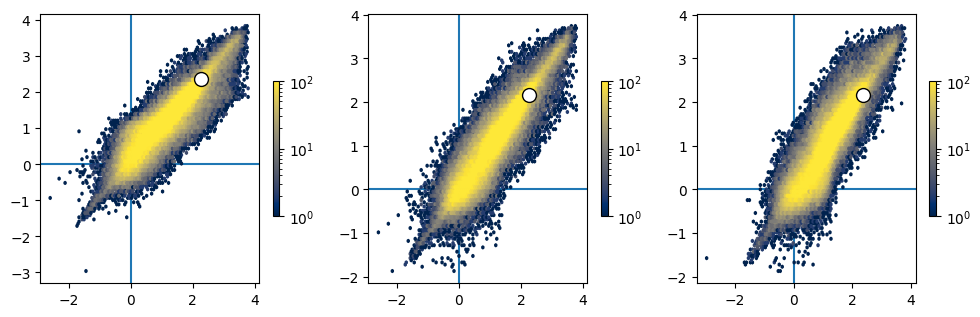

In [5]:
fig, ax = plt.subplots(1,3, figsize=(12,3.5))

hexbin_plot(ramr_dataset, x='fold_induction_1S-TIQ_inf', y='fold_induction_1R-TIQ_inf', ax=ax[0])
hexbin_plot(ramr_dataset, x='fold_induction_1S-TIQ_inf', y='fold_induction_1-DIQ_inf', ax=ax[1])
hexbin_plot(ramr_dataset, x='fold_induction_1R-TIQ_inf', y='fold_induction_1-DIQ_inf', ax=ax[2])

ax[0].scatter(ramr_dataset.loc['WT']["fold_induction_1S-TIQ_inf"], ramr_dataset.loc['WT']["fold_induction_1R-TIQ_inf"], ec='k', c='white', s=100)
ax[1].scatter(ramr_dataset.loc['WT']["fold_induction_1S-TIQ_inf"], ramr_dataset.loc['WT']["fold_induction_1-DIQ_inf"], ec='k', c='white', s=100)
ax[2].scatter(ramr_dataset.loc['WT']["fold_induction_1R-TIQ_inf"], ramr_dataset.loc['WT']["fold_induction_1-DIQ_inf"], ec='k', c='white', s=100)

ax[0].axvline(0, zorder=-1)
ax[0].axhline(0, zorder=-1)

ax[1].axvline(0, zorder=-1)
ax[1].axhline(0, zorder=-1)

ax[2].axvline(0, zorder=-1)
ax[2].axhline(0, zorder=-1)

plt.savefig("HTHTR_SALTY_inf.pdf", bbox_inches='tight')

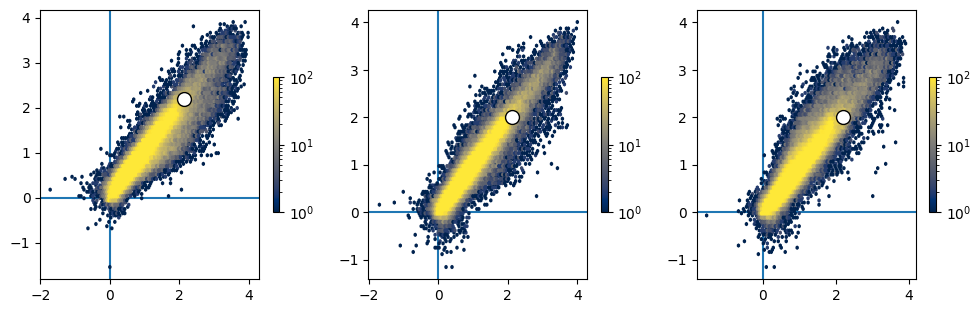

In [6]:
fig, ax = plt.subplots(1,3, figsize=(12,3.5))

hexbin_plot(ramr_dataset, x='fold_induction_1S-TIQ_500', y='fold_induction_1R-TIQ_500', ax=ax[0])
hexbin_plot(ramr_dataset, x='fold_induction_1S-TIQ_500', y='fold_induction_1-DIQ_500', ax=ax[1])
hexbin_plot(ramr_dataset, x='fold_induction_1R-TIQ_500', y='fold_induction_1-DIQ_500', ax=ax[2])

ax[0].scatter(ramr_dataset.loc['WT']["fold_induction_1S-TIQ_500"], ramr_dataset.loc['WT']["fold_induction_1R-TIQ_500"], ec='k', c='white', s=100)
ax[1].scatter(ramr_dataset.loc['WT']["fold_induction_1S-TIQ_500"], ramr_dataset.loc['WT']["fold_induction_1-DIQ_500"], ec='k', c='white', s=100)
ax[2].scatter(ramr_dataset.loc['WT']["fold_induction_1R-TIQ_500"], ramr_dataset.loc['WT']["fold_induction_1-DIQ_500"], ec='k', c='white', s=100)

ax[0].axvline(0, zorder=-1)
ax[0].axhline(0, zorder=-1)

ax[1].axvline(0, zorder=-1)
ax[1].axhline(0, zorder=-1)

ax[2].axvline(0, zorder=-1)
ax[2].axhline(0, zorder=-1)

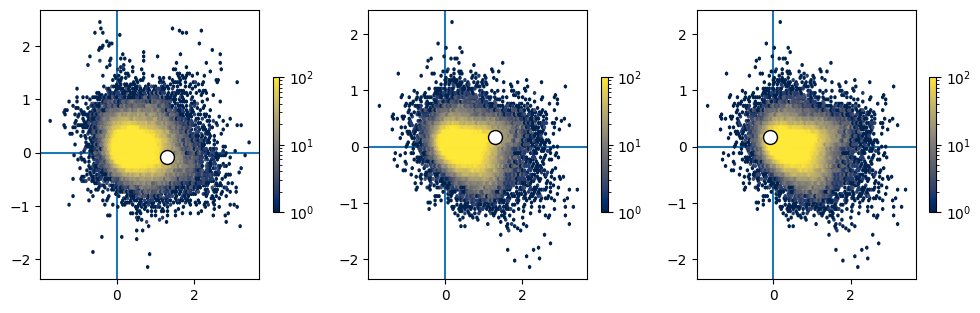

In [7]:
fig, ax = plt.subplots(1,3, figsize=(12,3.5))

hexbin_plot(ramr_dataset, x='log_g_32_1S-TIQ', y='log_g_32_1R-TIQ', ax=ax[0])
hexbin_plot(ramr_dataset, x='log_g_32_1S-TIQ', y='log_g_32_1-DIQ', ax=ax[1])
hexbin_plot(ramr_dataset, x='log_g_32_1S-TIQ', y='log_g_32_1-DIQ', ax=ax[2])

ax[0].scatter(ramr_dataset.loc['WT']["log_g_32_1S-TIQ"], ramr_dataset.loc['WT']["log_g_32_1R-TIQ"], ec='k', c='white', s=100)
ax[1].scatter(ramr_dataset.loc['WT']["log_g_32_1S-TIQ"], ramr_dataset.loc['WT']["log_g_32_1-DIQ"], ec='k', c='white', s=100)
ax[2].scatter(ramr_dataset.loc['WT']["log_g_32_1R-TIQ"], ramr_dataset.loc['WT']["log_g_32_1-DIQ"], ec='k', c='white', s=100)

ax[0].axvline(0, zorder=-1)
ax[0].axhline(0, zorder=-1)

ax[1].axvline(0, zorder=-1)
ax[1].axhline(0, zorder=-1)

ax[2].axvline(0, zorder=-1)
ax[2].axhline(0, zorder=-1)

plt.savefig("HTHTR_SALTY_v1.pdf", bbox_inches='tight')

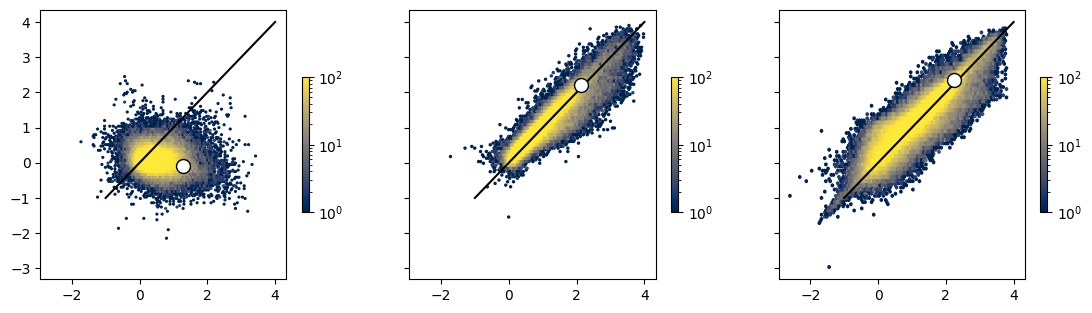

In [8]:
fig, ax = plt.subplots(1,3, figsize=(13.5,3.5), sharex=True, sharey=True)
hexbin_plot(ramr_dataset, x='log_g_32_1S-TIQ', y='log_g_32_1R-TIQ', ax=ax[0])
ax[0].plot([-1, 4], [-1, 4], c='k')
hexbin_plot(ramr_dataset, x='fold_induction_1S-TIQ_500', y='fold_induction_1R-TIQ_500', ax=ax[1])
ax[1].plot([-1, 4], [-1, 4], c='k')
hexbin_plot(ramr_dataset, x='fold_induction_1S-TIQ_inf', y='fold_induction_1R-TIQ_inf', ax=ax[2])
ax[2].plot([-1, 4], [-1, 4], c='k')

ax[0].scatter(ramr_dataset.loc['WT']["log_g_32_1S-TIQ"], ramr_dataset.loc['WT']["log_g_32_1R-TIQ"], ec='k', c='white', s=100, zorder=100)
ax[1].scatter(ramr_dataset.loc['WT']["fold_induction_1S-TIQ_500"], ramr_dataset.loc['WT']["fold_induction_1R-TIQ_500"], ec='k', c='white', s=100, zorder=100)
ax[2].scatter(ramr_dataset.loc['WT']["fold_induction_1S-TIQ_inf"], ramr_dataset.loc['WT']["fold_induction_1R-TIQ_inf"], ec='k', c='white', s=100, zorder=100)

plt.savefig("SALTY_v4.pdf", bbox_inches="tight")

In [9]:
ramr_dataset.columns

Index(['total_counts', 'long_read_count', 'log_g0', 'log_g0_err',
       'log_ginf_1-DIQ', 'log_ginf_1-DIQ_err', 'log_ec50_1-DIQ',
       'log_ec50_1-DIQ_err', 'log_ginf_1R-TIQ', 'log_ginf_1R-TIQ_err',
       'log_ec50_1R-TIQ', 'log_ec50_1R-TIQ_err', 'log_ginf_1S-TIQ',
       'log_ginf_1S-TIQ_err', 'log_ec50_1S-TIQ', 'log_ec50_1S-TIQ_err',
       'spec_1-DIQ', 'spec_1-DIQ_err', 'spec_1R-TIQ', 'spec_1R-TIQ_err',
       'spec_1S-TIQ', 'spec_1S-TIQ_err', 'mean_log_ec50', 'mean_log_ec50_err',
       'GP_log_g500_1-DIQ', 'GP_log_g500_1-DIQ_err', 'GP_log_g500_1R-TIQ',
       'GP_log_g500_1R-TIQ_err', 'GP_log_g500_1S-TIQ',
       'GP_log_g500_1S-TIQ_err', 'GP_log_g0', 'GP_log_g0_err',
       'log_g_32_1-DIQ', 'log_g_32_1-DIQ_err', 'log_g_32_1R-TIQ',
       'log_g_32_1R-TIQ_err', 'log_g_32_1S-TIQ', 'log_g_32_1S-TIQ_err',
       'GP_spec_1-DIQ', 'GP_spec_1-DIQ_err', 'GP_spec_1R-TIQ',
       'GP_spec_1R-TIQ_err', 'GP_spec_1S-TIQ', 'GP_spec_1S-TIQ_err',
       'mean_log_g_32', 'mean_log_g_32_err'

In [10]:
from scipy.optimize import curve_fit

def hill_curve(x, EC50, max_response=1, baseline_response=0, n=1):

    theta = x**n / (EC50 + x**n)
    return theta * max_response + baseline_response

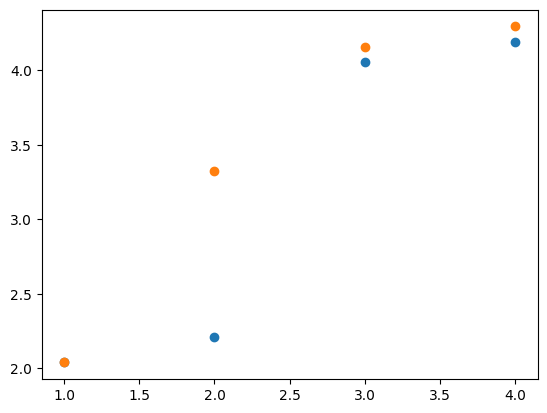

In [11]:
wt_data = ramr_dataset.loc['WT'][['log_g0', 'log_g_32_1-DIQ', 'GP_log_g500_1-DIQ', 'log_ginf_1-DIQ']].copy()
wt_data['log_g32_1-DIQ'] = wt_data['log_g0'] + wt_data['log_g_32_1-DIQ']

plt.scatter([1,2,3,4], wt_data[['log_g0', 'log_g32_1-DIQ','GP_log_g500_1-DIQ', 'log_ginf_1-DIQ']])

wt_data = ramr_dataset.loc['WT'][['log_g0', 'log_g_32_1S-TIQ', 'GP_log_g500_1S-TIQ', 'log_ginf_1S-TIQ']].copy()
wt_data['log_g32_1S-TIQ'] = wt_data['log_g0'] + wt_data['log_g_32_1S-TIQ']

plt.scatter([1,2,3,4], wt_data[['log_g0', 'log_g32_1S-TIQ','GP_log_g500_1S-TIQ', 'log_ginf_1S-TIQ']])
# wt_data = ramr_dataset.loc['WT'][['log_g0', 'log_g_32_1-DIQ', 'GP_log_g500_1-DIQ', 'log_ginf_1-DIQ']].copy()
# wt_data['log_g32_1-DIQ'] = wt_data['log_g0'] + wt_data['log_g_32_1-DIQ']

# plt.scatter([1,2,3,4], wt_data[['log_g0', 'log_g32_1-DIQ','GP_log_g500_1-DIQ', 'log_ginf_1-DIQ']])

In [28]:
ramr_dataset

,total_counts,long_read_count,log_g0,log_g0_err,log_ginf_1-DIQ,log_ginf_1-DIQ_err,log_ec50_1-DIQ,log_ec50_1-DIQ_err,log_ginf_1R-TIQ,log_ginf_1R-TIQ_err,...,mutated_sequence,DMS_score,fold_induction_1-DIQ_inf,fold_induction_1R-TIQ_inf,fold_induction_1S-TIQ_inf,mean_fold_induction,fold_induction_1-DIQ_500,fold_induction_1R-TIQ_500,fold_induction_1S-TIQ_500,specificity_category
substitutions,,,,,,,,,,,,,,,,,,,,,
A102D,149855.0,324.0,2.186602,0.047514,4.441684,0.352732,2.045024,0.236794,4.475088,0.325264,...,MVARPKSEDKKQALLEAATQAIAQSGIAASTAVIARNAGVAEGTLF...,2.255081,2.255081,2.288485,1.906652,2.150073,2.191988,2.179643,1.845873,native-specificity
A102D:A124T,4691.0,15.0,2.752385,0.032943,3.319031,1.184503,2.853527,0.852426,4.174289,0.505322,...,MVARPKSEDKKQALLEAATQAIAQSGIAASTAVIARNAGVAEGTLF...,0.566646,0.566646,1.421905,1.167355,1.051969,0.683095,0.930570,0.687975,native-specificity
A102D:A160T,1321.0,3.0,3.123051,0.164687,3.266337,1.288451,2.849485,1.034728,3.613351,1.135710,...,MVARPKSEDKKQALLEAATQAIAQSGIAASTAVIARNAGVAEGTLF...,0.143286,0.143286,0.490300,0.351456,0.328347,0.430879,0.548694,0.513984,inactive
A102D:C135S:M141V,2047.0,4.0,2.669250,0.047954,3.902472,0.590452,1.833818,0.642069,4.032528,0.569402,...,MVARPKSEDKKQALLEAATQAIAQSGIAASTAVIARNAGVAEGTLF...,1.233222,1.233222,1.363279,1.227681,1.274727,0.744495,0.708210,0.805905,native-specificity
A102D:D146V,4049.0,18.0,2.803850,0.025954,4.137924,0.561572,2.067763,0.529980,4.265019,0.434837,...,MVARPKSEDKKQALLEAATQAIAQSGIAASTAVIARNAGVAEGTLF...,1.334074,1.334074,1.461170,1.321535,1.372260,0.827335,1.045965,0.941785,native-specificity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Y93S:R137C:S138G,1569.0,2.0,1.593245,0.530506,2.416311,1.178133,2.867981,1.077249,2.561052,0.797930,...,MVARPKSEDKKQALLEAATQAIAQSGIAASTAVIARNAGVAEGTLF...,0.823066,0.823066,0.967807,0.885280,0.892051,0.766980,0.915570,0.824375,inactive
Y93S:S145T:Y148N,7742.0,13.0,1.662183,0.344688,3.348773,0.726688,2.730564,0.780892,3.109475,0.571525,...,MVARPKSEDKKQALLEAATQAIAQSGIAASTAVIARNAGVAEGTLF...,1.686590,1.686590,1.447292,2.397616,1.843833,1.142507,1.144112,1.764827,native-specificity
Y93T,395325.0,69.0,1.804907,0.068570,3.921875,0.585120,3.434163,0.550161,3.698776,0.611956,...,MVARPKSEDKKQALLEAATQAIAQSGIAASTAVIARNAGVAEGTLF...,2.116968,2.116968,1.893868,2.558529,2.189788,1.059503,0.989003,1.737058,native-specificity


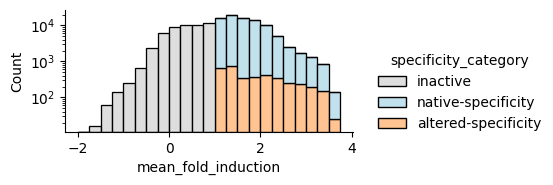

In [39]:
sns.displot(data=ramr_dataset, x="mean_fold_induction", hue="specificity_category", multiple='stack', 
            palette={'native-specificity': 'lightblue', 'inactive':'lightgray', 'altered-specificity':'xkcd:apricot'},
            height=2, aspect=2, bins=np.arange(-2,4,0.25), hue_order=("inactive", "native-specificity", "altered-specificity"))

plt.yscale('log')

# Get current axes and y-limits
ax = plt.gca()
ylim = ax.get_ylim()
ymin = ylim[0]

# Truncate all bar patches
for patch in ax.patches:
    # Get current bar position and height
    bbox = patch.get_bbox()
    x0, y0, x1, y1 = bbox.x0, bbox.y0, bbox.x1, bbox.y1
    
    # If bar extends below ymin, truncate it
    if y0 < ymin:
        patch.set_y(ymin)
        patch.set_height(y1 - ymin)

plt.savefig('ramr_log_histogram_all.pdf')

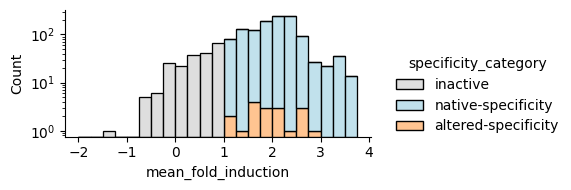

In [40]:
sns.displot(data=ramr_dataset.loc[ramr_dataset.n_subs==1], x="mean_fold_induction", hue="specificity_category", multiple='stack', 
            palette={'native-specificity': 'lightblue', 'inactive':'lightgray', 'altered-specificity':'xkcd:apricot'},
            height=2, aspect=2, bins=np.arange(-2,4,0.25), hue_order=("inactive", "native-specificity", "altered-specificity"))

plt.yscale('log')

# Get current axes and y-limits
ax = plt.gca()
ylim = ax.get_ylim()
ymin = ylim[0]

# Truncate all bar patches
for patch in ax.patches:
    # Get current bar position and height
    bbox = patch.get_bbox()
    x0, y0, x1, y1 = bbox.x0, bbox.y0, bbox.x1, bbox.y1
    
    # If bar extends below ymin, truncate it
    if y0 < ymin:
        patch.set_y(ymin)
        patch.set_height(y1 - ymin)

plt.savefig('ramr_log_histogram_singles.pdf')

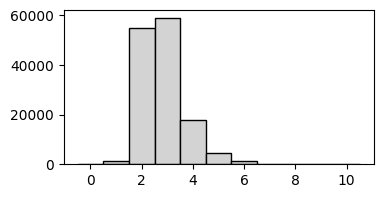

In [52]:
plt.figure(figsize=(4,2))
plt.hist(ramr_dataset.n_subs, bins=np.arange(-0.5,11.5), ec='k', color='lightgray')
plt.savefig('ramr_variant_distribution.pdf', bbox_inches='tight')

AttributeError: Rectangle.set() got an unexpected keyword argument 'type'

<Figure size 400x150 with 0 Axes>

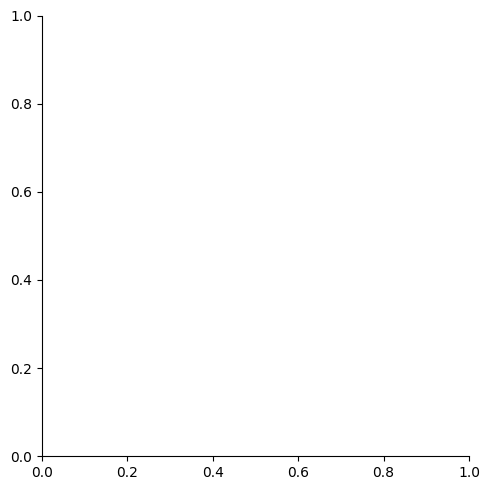

In [32]:
plt.figure(figsize=(4,1.5))
sns.displot(ramr_dataset, x='mean_fold_induction', type='hist', hue="specificity_category", multiple='stack')
plt.axvline(ramr_dataset['mean_fold_induction'].loc['WT'], c='k')
plt.axvline(1., c='k', ls='--')

In [12]:
popt, pcov = curve_fit(hill_curve, [0, 32, 500, 10000], 
          10**wt_data[['log_g0', 'log_g32_1-DIQ', 'GP_log_g500_1-DIQ', 'log_ginf_1-DIQ']].values, 
          p0=(10, 100, 10000, 1))

print(popt)

KeyError: "['log_g32_1-DIQ', 'GP_log_g500_1-DIQ', 'log_ginf_1-DIQ'] not in index"

In [ ]:
def log_hill_curve(log_x, EC50, max_response=1, baseline_response=0, n=1):

    x = 10**log_x
    theta = x**n / (EC50 + x**n)
    return np.log10(theta * max_response + baseline_response)

In [ ]:
xx = 10**x
theta = xx**2 / (100 + xx**2)
np.log10(theta * 10 + 2)

In [ ]:
log_hill_curve(x, 100)

In [ ]:
wt_data = ramr_dataset.loc['WT'][['log_g0', 'log_g_32_1S-TIQ', 'GP_log_g500_1S-TIQ', 'log_ginf_1S-TIQ']].copy()
wt_data['log_g32_1S-TIQ'] = wt_data['log_g0'] + wt_data['log_g_32_1S-TIQ']

popt_1S, pcov = curve_fit(log_hill_curve, [-10, np.log10(32), np.log10(500), 6], 
          wt_data[['log_g0', 'log_g32_1S-TIQ', 'GP_log_g500_1S-TIQ', 'log_ginf_1S-TIQ']].values, 
          p0=(10, 100, 10000, 1))

x = np.linspace(0, 4, 100)
# y = hill_curve(x, 
#            EC50=10**ramr_dataset.loc['WT']['log_ec50_1-DIQ'],
#           baseline_response=10**ramr_dataset.loc['WT']['log_g0'],
#           max_response=10**ramr_dataset.loc['WT']['log_ginf_1-DIQ'],
#               n=2) 

y = log_hill_curve(x, *popt_1S)

plt.plot(x, y)

# wt_data = ramr_dataset.loc['WT'][['log_g0', 'log_g_32_1-DIQ', 'GP_log_g500_1-DIQ', 'log_ginf_1-DIQ']].copy()
# wt_data['log_g32_1-DIQ'] = wt_data['log_g0'] + wt_data['log_g_32_1-DIQ']

plt.scatter([-1, np.log10(32), np.log10(500), 5], wt_data[['log_g0', 'log_g32_1S-TIQ', 'GP_log_g500_1S-TIQ', 'log_ginf_1S-TIQ']])

wt_data = ramr_dataset.loc['WT'][['log_g0', 'log_g_32_1R-TIQ', 'GP_log_g500_1R-TIQ', 'log_ginf_1R-TIQ']].copy()
wt_data['log_g32_1R-TIQ'] = wt_data['log_g0'] + wt_data['log_g_32_1R-TIQ']

popt_1R, pcov = curve_fit(log_hill_curve, [-10, np.log10(32), np.log10(500), 6], 
          wt_data[['log_g0', 'log_g32_1R-TIQ', 'GP_log_g500_1R-TIQ', 'log_ginf_1R-TIQ']].values, 
          p0=(150, 300, 10000, 3),
          bounds=([50, 1, 1000, 0.1], [150, 10**5, 10**6, 10]))

print(popt_1R)

x = np.linspace(0, 4, 100)
# y = hill_curve(x, 
#            EC50=10**ramr_dataset.loc['WT']['log_ec50_1-DIQ'],
#           baseline_response=10**ramr_dataset.loc['WT']['log_g0'],
#           max_response=10**ramr_dataset.loc['WT']['log_ginf_1-DIQ'],
#               n=2) 

y = log_hill_curve(x, *popt_1R)

plt.plot(x, y)

# wt_data = ramr_dataset.loc['WT'][['log_g0', 'log_g_32_1-DIQ', 'GP_log_g500_1-DIQ', 'log_ginf_1-DIQ']].copy()
# wt_data['log_g32_1-DIQ'] = wt_data['log_g0'] + wt_data['log_g_32_1-DIQ']

plt.scatter([-1, np.log10(32), np.log10(500), 5], wt_data[['log_g0', 'log_g32_1R-TIQ', 'GP_log_g500_1R-TIQ', 'log_ginf_1R-TIQ']])

In [ ]:
popt_1S

In [ ]:
plt.figure(figsize=(6,2))

def hill_curve(x, EC50, max_response=1, baseline_response=0, n=1):

    theta = x**n / (EC50 + x**n)
    return theta * max_response + baseline_response

wt_data = ramr_dataset.loc['WT'][['log_g0', 'log_g_32_1S-TIQ', 'GP_log_g500_1S-TIQ', 'log_ginf_1S-TIQ']].copy()
wt_data['log_g32_1S-TIQ'] = wt_data['log_g0'] + wt_data['log_g_32_1S-TIQ']

x_vals = [0.1, 32, 500, 10000]
popt_1S, pcov = curve_fit(hill_curve, x_vals, 
          10**wt_data[['log_g0', 'log_g32_1S-TIQ', 'GP_log_g500_1S-TIQ', 'log_ginf_1S-TIQ']].values, 
          p0=(10, 100, 10000, 1))

print(popt_1S)

x = np.logspace(0, 4, 100)
y = hill_curve(x, *popt_1S)

plt.scatter([0.1, 32, 500, 100000], 10**wt_data[['log_g0', 'log_g32_1S-TIQ', 'GP_log_g500_1S-TIQ', 'log_ginf_1S-TIQ']])
plt.xscale('log'); plt.yscale('log')

plt.plot(x, y);


wt_data = ramr_dataset.loc['WT'][['log_g0', 'log_g_32_1R-TIQ', 'GP_log_g500_1R-TIQ', 'log_ginf_1R-TIQ']].copy()
wt_data['log_g32_1R-TIQ'] = wt_data['log_g0'] + wt_data['log_g_32_1R-TIQ']
wt_data['cheating_for_a_better_purely_illustrative_fit'] = wt_data['log_g0'] - wt_data['log_g_32_1R-TIQ'] 

x_vals = [0.1, 32, 500, 10000]
popt_1R, pcov = curve_fit(hill_curve, x_vals, 
          10**wt_data[['log_g0', 'cheating_for_a_better_purely_illustrative_fit', 'GP_log_g500_1R-TIQ', 'log_ginf_1R-TIQ']].values, 
          p0=(300, 100, 10000, 5))

print(popt_1R)

x = np.logspace(0, 4, 100)
y = hill_curve(x, *popt_1R)

plt.scatter([0.1, 32, 500, 100000], 10**wt_data[['log_g0', 'log_g32_1R-TIQ', 'GP_log_g500_1R-TIQ', 'log_ginf_1R-TIQ']])
plt.xscale('log'); plt.yscale('log')

plt.plot(x, y);

wt_data = ramr_dataset.loc['WT'][['log_g0', 'log_g_32_1-DIQ', 'GP_log_g500_1-DIQ', 'log_ginf_1-DIQ']].copy()
wt_data['log_g32_1-DIQ'] = wt_data['log_g0'] + wt_data['log_g_32_1-DIQ']

x_vals = [0.1, 32, 500, 10000]
popt_diq, pcov = curve_fit(hill_curve, x_vals, 
          10**wt_data[['log_g0', 'log_g32_1-DIQ', 'GP_log_g500_1-DIQ', 'log_ginf_1-DIQ']].values, 
          p0=(300, 100, 10000, 5))

print(popt_diq)

x = np.logspace(0, 4, 100)
y = hill_curve(x, *popt_diq)

plt.scatter([0.1, 32, 500, 100000], 10**wt_data[['log_g0', 'log_g32_1-DIQ', 'GP_log_g500_1-DIQ', 'log_ginf_1-DIQ']])
plt.xscale('log'); plt.yscale('log')

plt.plot(x, y);

plt.savefig('illustrative_dose_response.pdf', bbox_inches='tight')

In [ ]:
wt_data[['log_g0', 'cheating_for_a_better_purely_illustrative_fit', 'GP_log_g500_1R-TIQ', 'log_ginf_1R-TIQ']].values

In [ ]:
wt_data['log_g_32_1R-TIQ']

In [ ]:
wt_data[['log_g0', 'log_g32_1R-TIQ', 'GP_log_g500_1R-TIQ', 'log_ginf_1R-TIQ']].values

In [ ]:
np.exp(ramr_dataset.loc['WT']['log_ec50_1-DIQ'])

In [ ]:
wt_data = ramr_dataset.loc['WT'][['log_g0', 'log_g_32_1-DIQ', 'GP_log_g500_1-DIQ', 'log_ginf_1-DIQ']].copy()
wt_data['log_g32_1-DIQ'] = wt_data['log_g0'] + wt_data['log_g_32_1-DIQ']

plt.scatter([1,2,3,4], wt_data[['log_g0', 'log_g32_1-DIQ','GP_log_g500_1-DIQ', 'log_ginf_1-DIQ']])

wt_data = ramr_dataset.loc['WT'][['log_g0', 'log_g_32_1S-TIQ', 'GP_log_g500_1S-TIQ', 'log_ginf_1S-TIQ']].copy()
wt_data['log_g32_1S-TIQ'] = wt_data['log_g0'] + wt_data['log_g_32_1S-TIQ']

plt.scatter([1,2,3,4], wt_data[['log_g0', 'log_g32_1S-TIQ','GP_log_g500_1S-TIQ', 'log_ginf_1S-TIQ']])

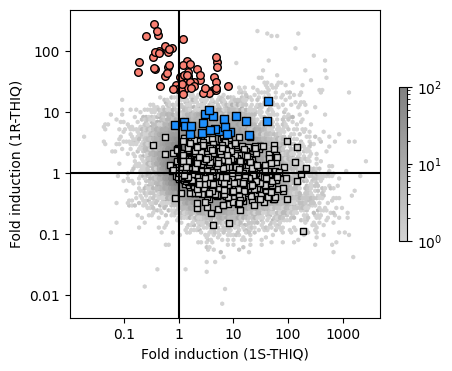

In [13]:
# Define two colors for the gradient
start_color = "lightgray"  # Red
end_color = "gray"    # Blue

from matplotlib.colors import LinearSegmentedColormap
# Create a custom colormap
custom_cmap = LinearSegmentedColormap.from_list("custom_gradient", [start_color, end_color])

fig,ax = plt.subplots(figsize=(5,4))
hexbin_plot(data=ramr_dataset, x='log_g_32_1S-TIQ', y='log_g_32_1R-TIQ', cmap=custom_cmap, ax=ax)


plt.axvline(0, zorder=10, c='k')
plt.axhline(0, zorder=10, c='k')

plt.scatter(data=ramr_dataset.loc[ramr_dataset.n_subs==1], x='log_g_32_1S-TIQ', y='log_g_32_1R-TIQ', c='lightgray', s=20, ec='k', marker='s')
plt.scatter(data=ramr_dataset.loc[(ramr_dataset.n_subs==1)&(ramr_dataset['log_g_32_1R-TIQ']>np.log10(4))], 
            x='log_g_32_1S-TIQ', y='log_g_32_1R-TIQ', c="dodgerblue", s=30, ec='k', marker='s')

plt.scatter(data=ramr_dataset.loc[(ramr_dataset['log_g_32_1S-TIQ']<np.log10(10))&(ramr_dataset['log_g_32_1R-TIQ']>np.log10(20))], 
            x='log_g_32_1S-TIQ', y='log_g_32_1R-TIQ', c="salmon", s=30, ec='k', marker='o')

plt.yticks([-2, -1, 0, 1, 2], [0.01, 0.1, 1, 10, 100])
plt.xticks([-1, 0, 1, 2, 3], [0.1, 1, 10, 100, 1000])
plt.ylabel("Fold induction (1R-THIQ)")
plt.xlabel("Fold induction (1S-THIQ)")

plt.savefig("HTHTR_SALTY_defplot.pdf", bbox_inches='tight')

In [ ]:
# Define two colors for the gradient
start_color = "lightgray"  # Red
end_color = "gray"    # Blue

from matplotlib.colors import LinearSegmentedColormap
# Create a custom colormap
custom_cmap = LinearSegmentedColormap.from_list("custom_gradient", [start_color, end_color])

fig,ax = plt.subplots(figsize=(5,4))
hexbin_plot(data=ramr_dataset, x='log_g_32_1S-TIQ', y='log_g_32_1-DIQ', cmap=custom_cmap, ax=ax)


plt.axvline(0, zorder=10, c='k')
plt.axhline(0, zorder=10, c='k')

plt.scatter(data=ramr_dataset.loc[ramr_dataset.n_subs==1], x='log_g_32_1S-TIQ', y='log_g_32_1-DIQ', c='lightgray', s=20, ec='k', marker='s')
plt.scatter(data=ramr_dataset.loc[(ramr_dataset.n_subs==1)&(ramr_dataset['log_g_32_1-DIQ']>np.log10(4))], 
            x='log_g_32_1S-TIQ', y='log_g_32_1-DIQ', c="dodgerblue", s=30, ec='k', marker='s')

plt.scatter(data=ramr_dataset.loc[(ramr_dataset['log_g_32_1S-TIQ']<np.log10(10))&(ramr_dataset['log_g_32_1-DIQ']>np.log10(20))], 
            x='log_g_32_1S-TIQ', y='log_g_32_1-DIQ', c="salmon", s=30, ec='k', marker='o')

plt.yticks([-2, -1, 0, 1, 2], [0.01, 0.1, 1, 10, 100])
plt.xticks([-1, 0, 1, 2, 3], [0.1, 1, 10, 100, 1000])
plt.ylabel("Fold induction (1-DIQ)")
plt.xlabel("Fold induction (1S-THIQ)")

plt.savefig("HTHTR_SALTY_defplot2.pdf", bbox_inches='tight')

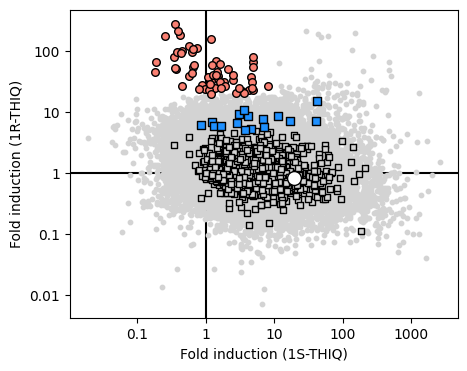

In [14]:
plt.figure(figsize=(5,4))
plt.axvline(0, zorder=-1, c='k')
plt.axhline(0, zorder=-1, c='k')
plt.scatter(data=ramr_dataset, x='log_g_32_1S-TIQ', y='log_g_32_1R-TIQ', c='lightgray', s=10)
plt.scatter(data=ramr_dataset.loc[ramr_dataset.n_subs==1], x='log_g_32_1S-TIQ', y='log_g_32_1R-TIQ', c='lightgray', s=20, ec='k', marker='s')
plt.scatter(data=ramr_dataset.loc[(ramr_dataset.n_subs==1)&(ramr_dataset['log_g_32_1R-TIQ']>0.7)], 
            x='log_g_32_1S-TIQ', y='log_g_32_1R-TIQ', c="dodgerblue", s=30, ec='k', marker='s')

plt.scatter(data=ramr_dataset.loc[(ramr_dataset['log_g_32_1S-TIQ']<np.log10(10))&(ramr_dataset['log_g_32_1R-TIQ']>np.log10(20))], 
            x='log_g_32_1S-TIQ', y='log_g_32_1R-TIQ', c="salmon", s=30, ec='k', marker='o')

plt.yticks([-2, -1, 0, 1, 2], [0.01, 0.1, 1, 10, 100])
plt.xticks([-1, 0, 1, 2, 3], [0.1, 1, 10, 100, 1000])
plt.ylabel("Fold induction (1R-THIQ)")
plt.xlabel("Fold induction (1S-THIQ)")

plt.scatter(ramr_dataset.loc['WT']["log_g_32_1S-TIQ"], ramr_dataset.loc['WT']["log_g_32_1R-TIQ"], ec='k', c='white', s=100, zorder=1000)

#plt.savefig("HTHTR_SALTY_v3.pdf", bbox_inches='tight')

In [ ]:
np.sum(row['log_g_32_1R-TIQ']>np.log10(5))

In [15]:
ramr_dataset = assign_mutant_column(ramr_dataset)

ramr_dataset = assign_specificity_categories(ramr_dataset,
                              lambda index,row: row.mean_fold_induction<1,
                              lambda index,row: row['log_g_32_1-DIQ']>np.log10(4) or row['log_g_32_1R-TIQ']>np.log10(4))

check_dataset(ramr_dataset)

ramr_dataset.to_csv("../../processed_data/HTHTR_SALTY_dOelsnitz_2025.csv")

Checking dataset table:
✅ DMS_score in table
✅ mutated_sequence in table
✅ mutant in table
✅ Contains WT sequence (M1M)
✅ all mutants pass checks and match sequence

✅ All checks passed!


In [ ]:
np.savetxt('../../processed_data/ramR_ESCOTT.mut', ramr_dataset.mutant.values, fmt="%s")
np.savetxt('../../processed_data/ramR_GEMME.mut', [i.replace(':',',') for i in ramr_dataset.mutant.values], fmt="%s")

In [ ]:
ramr_dataset

In [25]:
ramR_singles = ramr_dataset.loc[ramr_dataset.n_subs==1]
ramR_singles['pos'] = [int(i[1:-1]) for i in ramR_singles.index]
ramR_singles['altered-specificity'] = ramR_singles.specificity_category == 'altered-specificity'
ramR_singles = ramR_singles[ramR_singles.pos > 0]

ramR_singles['count'] = 1
sum_altsp = ramR_singles.groupby('pos').sum(['altered-specificity', 'count'])[['altered-specificity', 'count']]
mean_altsp = sum_altsp['altered-specificity']/(sum_altsp['count'] + 0.5)
altsp = mean_altsp.loc[mean_altsp>0]

print(f"create RamR_specificity, RamR and name CA and chain C and resi {'+'.join([str(i) for i in altsp.index])}")

print('color marine, RamR_specificity')
print('show spheres, RamR_specificity')
print('hide cartoon, RamR_specificity')

for pos,n in altsp.items():
    print(f"set sphere_scale, {n*6}, RamR_specificity and res {pos};")

create RamR_specificity, RamR and name CA and chain C and resi 64+70+89+98+99+100+103+125+129+135+138+139+160
color marine, RamR_specificity
show spheres, RamR_specificity
hide cartoon, RamR_specificity
set sphere_scale, 1.0285714285714285, RamR_specificity and res 64;
set sphere_scale, 0.9230769230769231, RamR_specificity and res 70;
set sphere_scale, 0.6153846153846154, RamR_specificity and res 89;
set sphere_scale, 0.631578947368421, RamR_specificity and res 98;
set sphere_scale, 0.631578947368421, RamR_specificity and res 99;
set sphere_scale, 0.631578947368421, RamR_specificity and res 100;
set sphere_scale, 0.8, RamR_specificity and res 103;
set sphere_scale, 0.3870967741935484, RamR_specificity and res 125;
set sphere_scale, 1.3333333333333333, RamR_specificity and res 129;
set sphere_scale, 0.6153846153846154, RamR_specificity and res 135;
set sphere_scale, 0.3076923076923077, RamR_specificity and res 138;
set sphere_scale, 0.6153846153846154, RamR_specificity and res 139;
set 

/tmp/ipykernel_3281889/212329501.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ramR_singles['pos'] = [int(i[1:-1]) for i in ramR_singles.index]
/tmp/ipykernel_3281889/212329501.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ramR_singles['altered-specificity'] = ramR_singles.specificity_category == 'altered-specificity'
